## KoChatGPT

In [ ]:
!pip install datasets
!pip install loralib
!pip install trl
!pip install accelerate
!pip install transformers

In [ ]:
import os

modifications = [
    {
        "file": "chatgpt/trainer/callbacks/save_checkpoint.py",
        "changes": [
            {"line": 3, "old": "from chatgpt.trainer.strategies import ColossalAIStrategy, Strategy",
             "new": "from chatgpt.trainer.strategies import Strategy"},
            {"line": 71, "old": "only_rank0 = not isinstance(self.strategy, ColossalAIStrategy)",
             "new": "            only_rank0 = not isinstance(self.strategy)"},
        ],
    },
    {
        "file": "chatgpt/trainer/strategies/__init__.py",
        "changes": [
            {"line": 1, "old": "from .colossalai import ColossalAIStrategy", "new": ""},  # 삭제
            {"line": 5, "old": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy', 'ColossalAIStrategy']",
             "new": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy']"},
        ],
    },
    {
        "file": "chatgpt/dataset/reward_dataset.py",
        "changes": [
            {"line": 3, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ],
    },
    {
        "file": "chatgpt/trainer/strategies/__init__.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    },
    {
        "file": "chatgpt/dataset/reward_dataset.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    }
]


def modify_file(file_path, changes):
    """파일에서 지정된 줄을 찾아 내용을 수정하는 함수"""

    if not os.path.exists(file_path):
        print(f"⚠️ 파일이 존재하지 않습니다: {file_path}")
        return

    with open(file_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    modified = False

    for change in changes:
        line_index = change["line"]
        if 0 <= line_index < len(lines):
            if lines[line_index].strip() == change["old"]:
                lines[line_index] = change["new"] + "\n"
                modified = True
            else:
                print(f"⚠️ {file_path} 파일의 {change['line']}번째 줄이 예상과 다릅니다.")
                print(f"   예상: {change['old']}")
                print(f"   실제: {lines[line_index].strip()}")

    if modified:
        with open(file_path, "w", encoding="utf-8") as file:
            file.writelines(lines)
        print(f"✅ 수정 완료: {file_path}")
    else:
        print(f"⚠️ {file_path} 수정할 내용이 없습니다.")

for mod in modifications:
    modify_file(mod["file"], mod["changes"])

In [4]:
import torch
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
import numpy

print("Torch version:{}".format(torch.__version__)) # Torch version:1.12.1
print("Cuda version: {}".format(torch.version.cuda)) # Cuda version: 11.3
print("transformers version: {}".format(transformers.__version__)) # transformers 4.28.0
print("GPU 사용 가능여부: {}".format(torch.cuda.is_available()))

# 만일 아래 모듈이 불러와지지 않는다면 Clone 및 수정을 잘 진행했는지 확인해주세요
from chatgpt.trainer.strategies import NaiveStrategy

Torch version:2.7.1+cu118
Cuda version: 11.8
transformers version: 5.9.0
GPU 사용 가능여부: True


#### BASE MODEL(KoGPT-2) 불러오기

In [5]:
from transformers import PreTrainedTokenizerFast
from transformers import GPT2LMHeadModel

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "skt/kogpt2-base-v2"
tokenizer = PreTrainedTokenizerFast.from_pretrained(model_name)
model = model = GPT2LMHeadModel.from_pretrained(model_name).to(device)

tokenizer.json:   0%|          | 0.00/2.83M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/513M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
tokenizer.model_max_length

1000000000000000019884624838656

최대 토큰 수 확인

In [7]:
model.config.n_positions

1024

모델이 한 번에 입력받고 처리할 수 있는 최대 토큰(단어 조각)의 개수

In [8]:
input_txt = "바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까."

In [9]:
tokens = tokenizer(input_txt).tokens()
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].numpy()

In [10]:
print(len(tokenizer.vocab))

51200


In [11]:
pd.options.display.max_columns = 40
pd.options.display.max_rows = 60
df = pd.DataFrame([tokens, input_ids[0]], index=["kogpt-2_tokens", "Input_IDs"])
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
kogpt-2_tokens,▁바람,도,▁없는,▁공중에,▁수직,의,▁파,문을,▁내,이며,▁고,요,히,▁떨어지는,▁오동,잎은,▁누,구의,▁발자,취,▁입,니까,.
Input_IDs,10891,7235,9712,49207,14438,8143,9203,9941,9094,9639,9065,8084,8811,21215,34769,19985,9669,10139,21626,8408,9241,23775,389


In [12]:
max_length=128
model.to(device)
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_greedy = model.generate(input_ids, max_length=max_length, do_sample=False)
print(tokenizer.decode(output_greedy[0]))

model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그렇다면 그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리요?"
"그건 무슨 소리


greedy search로 input에 대한 text 생성 -> 반복적인 텍스트 출력

#### beam search 디코딩 사용, n-gram 패널티 부과

In [13]:
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_beam = model.generate(input_ids, max_length=max_length, num_beams=10, no_repeat_ngram_size=2,
                             do_sample=False)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"그렇지 않습니다."
"어떻게 된 일입니까?"
그녀는 고개를 갸웃거렸다.
"아니, 그게 무슨 말씀이신지 모르겠습니다만."
"무슨 말씀인지 알 수가 없군요."
아무런 대답도 하지 않은 채 그녀는 고개를 끄덕였다.
"그래, 알았어."
그녀의 눈에서 눈물이 주르륵 흘러내렸다.
그녀가 다시 입을 열었다.
"정말 죄송합니다, 고마워요, 고맙습니다"
"


In [14]:
output_beam = model.generate(input_ids, max_length=max_length, num_beams=7, no_repeat_ngram_size=2,
                             do_sample=True, temperature=2.0, top_k=50)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까."
"그렇습니다. 저는 저와 같은 길을 걸어온 사람이에요."
그러자 두 사람의 눈길이 마주쳤다.
"저 또한 저를 만나러 왔습니다."
그들은 고개를 숙인 채 악수를 청했다.
그런데도 그들의 시선은 서로 마주치지 않았다.
서로를 향해 손을 흔들며 손짓을 보내던 그들의 눈빛도 잠시 멈춰 섰을 뿐이었다.
그때 한 노인이 나타났다.
"이제 그만 하십시오."
"무슨 일입니까."
노인은 그 노인에 대해 아무런 말도 하지


#### top_p 샘플링

top_p는 Nucleus Sampling이라고도 불리며, 단어 선택 시 확률 누적 기준으로 상위 p%의 단어들만 고려하는 방법

In [15]:
output_beam = model.generate(input_ids, max_length=max_length, num_beams=7, no_repeat_ngram_size=2,
                             do_sample=True, top_p=0.90)
print(tokenizer.decode(output_beam[0]))

바람도 없는 공중에 수직의 파문을 내이며 고요히 떨어지는 오동잎은 누구의 발자취 입니까.'
"아니, 그게 무슨 소리예요?"
"그런데 그건 좀 이상한 일이야."
"어떻게 된 거예요."
그녀는 고개를 갸우뚱거렸다.
"이봐, 이봐. 이게 뭐야? 이거 뭔데. 어째서 이 녀석이 그걸 모를까."
그녀의 눈에는 눈물이 고여 있었다.
"뭐, 그거야. 아까도 말했잖아. 왜 이걸 몰라서 그러는지 모르겠어."



### 데이터셋 확인

#### 1. SFT 데이터셋

명령어(prompt)와 모범 답변(completion) 쌍으로 구성된 12,000개 데이터

In [16]:
import json
data_path_1_SFT = '/home/jovyan/work/KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl'
with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)
print(len(list_data_dict))
list_data_dict[:3]

12000


[{'prompt': '불고기용 고기 한우에요?',
  'completion': "'저는 인공지능 챗봇이며, 직접적으로 식품에 관한 정보를 가지고 있지 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 하지만 한우는 대표적인 고급 육류로 알려져 있기 때문에, 한우를 사용하는 경우도 많습니다. 알러지나 개별 건강 상태에 따라 다를 수 있으니 충분한 정보 수집 후에 선택해 주시기 바랍니다.",
  'tokens': 193},
 {'prompt': '쓰던 앱이 유료로 전환됐어',
  'completion': "'어떤 앱인지 모르기 때문에 정확한 답변을 드리기 어렵습니다. 하지만, 일반적으로 유료 전환된 앱은 기존 무료 앱에서 추가적인 기능이나 서비스를 제공하는 경우가 많습니다. 이 경우, 유료 전환 이전 가격이 매우 저렴하거나 무료인 경우가 많으므로, 앱을 계속 사용하려면 추가적인 비용을 지불해야 할 수 있습니다. 하지만, 유료 전환 이후에는 기존 사용자 또는 새로운 사용자 모두가 추가 기능과 높은 품질의 서비스를 이용할 수 있게 됩니다. 따라서, 앱 개발자는 유료 모델로 전환함으로써 앱의 수익을 증가시키고 더 나은 서비스를 제공할 수 있습니다.",
  'tokens': 288},
 {'prompt': '여친이랑 다툼',
  'completion': "'저는 인공지능이기 때문에 여친과의 다툼에 대해서는 조언을 드릴 수는 없습니다. 하지만 다투게 되면 상대방의 말을 경청하는 태도와 서로의 감정을 존중하는 것이 중요합니다. 논리적이고 차분한 대화를 통해 문제를 해결해보세요. 그리고 서로를 이해하고 서로의 의견을 수용하는 것이 중요합니다.",
  'tokens': 153}]

#### 2. RM 데이터셋

질문에 대한 3가지 답변 후보와 이에 대한 인간의 순위 선호도(ranking)가 기록된 10,220개 데이터

In [17]:
data_path_2_RM = '/home/jovyan/work/KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl'
with open(data_path_2_RM, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

10220


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?',
  'completion_0': 'Allow me to answer your question. I know that you are curious about me.',
  'completion_1': '번디는 다양한 인터뷰자들과 뉴스홍보 담당자들과의 면담 때 밝혔다.',
  'completion_2': '라이언에게 말했다.',
  'ranking': [2, 1, 0]},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?',
  'completion_0': '개포주공아파트는 다섯 단지로 이루어져 있습니다.',
  'completion_1': '이날 목송에서 구글상위노',
  'completion_2': '개포주공아파트는 총 27개 단지로 이루어져 있습니다.',
  'ranking': [2, 0, 1]},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?',
  'completion_0': 'The diameter of the Metallic domain is bigger than the Hyperonic domain.',
  'completion_1': '이 질문은 조금 불분명합니다. 김영삼 대통령이 후보 시절에 어떤 발언을 했고, 누가 그 발언을 문제삼았는지에 따라 답이 다를 수 있습니다.\\n\\n만약 김영삼 대통령이 후보 시절에 지역표심을 겨냥한 발언을 했다는 가정하에, 그 발언을 문제삼은 후보가 누구였는지를 대답하자면, 그 답은 이화선 당시 민주당 대통령 후보가 될 것입니다. 1992년 총선 때, 김영삼 대선후보는 "집값이 오른 노량진역 부근의 부동산 가격은 세월호 폭침 후 \\\'강남 도시재생\\\' 일환으로 상승했다"는 발언을 했습니다. 하지만 이화선 후보는 이 발언을 "전국적으로 경제적 발전이 이루어지지 않은 지방민의 마음을 멀리해지려는 무례한 발언"이라고 비판하며 문

#### 3. PPO 데이터셋

강화학습에 사용할 질문(prompt)만 모아둔 12,000개 데이터

In [18]:
data_path_3_PPO = '/home/jovyan/work/KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl'
with open(data_path_3_PPO, "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

print(len(list_data_dict))
list_data_dict[:3]

12000


[{'prompt': '번디는 자신이 탐정잡지, 범죄소설 그리고 성범죄 관련 실제 범죄 다큐멘터리들을 탐독했다고 누구에게 말했나?'},
 {'prompt': '개포주공아파트는 몇 단지로 이루어져 있나?'},
 {'prompt': '김영삼의 후보 시절 지역표심을 겨냥한 발언을 문제삼은 후보는?'}]

### RLHF 학습 진행

#### STEP 1 - Supervised Fine-Tuning (SFT)

In [19]:
from typing import Optional, Dict, Sequence
from torch.utils.data import Dataset
from dataclasses import dataclass
import logging
import copy

In [ ]:
from transformers import PreTrainedTokenizerFast
from transformers import GPT2LMHeadModel

model = GPT2LMHeadModel.from_pretrained('skt/kogpt2-base-v2')

tokenizer = PreTrainedTokenizerFast.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

print(tokenizer)

In [21]:
class SFT_dataset(Dataset):

    def __init__(self, data_path_1_SFT: str, tokenizer: transformers.PreTrainedTokenizer, verbose=False):
        super(SFT_dataset, self).__init__()
        logging.warning("Loading data...")

        pattern_instruction = 'prompt'  # instruction
        pattern_output = 'completion'  # response

        with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
            list_data_dict = json.load(json_file)

        PROMPT_DICT = {
            "prompt_input": (
                "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
            )
        }

        prompt_input = PROMPT_DICT["prompt_input"]

        sources = []
        for example in list_data_dict:
            tmp = prompt_input.format_map(example)
            sources.append(tmp)

        targets = []
        for example in list_data_dict:
            targets.append(f"{example[pattern_output]}{tokenizer.eos_token}")
        examples = [s + t for s, t in zip(sources, targets)]

        sources_tokenized = self._tokenize_fn(sources, tokenizer)  # source
        examples_tokenized = self._tokenize_fn(examples, tokenizer)  # source + target

        input_ids = examples_tokenized["input_ids"]
        labels = copy.deepcopy(input_ids)
        for label, source_len in zip(labels, sources_tokenized["input_ids_lens"]):
            label[:source_len] = -100

        data_dict = dict(input_ids=input_ids, labels=labels)

        self.input_ids = data_dict["input_ids"]
        self.labels = data_dict["labels"]
        logging.warning("Loading data done!!: %d"%(len(self.labels)))


    def _tokenize_fn(self, strings: Sequence[str], tokenizer: transformers.PreTrainedTokenizer) -> Dict:
        tokenized_list = [
            tokenizer(
                text,
                return_tensors="pt",
                padding="longest",
                max_length=tokenizer.model_max_length,
                truncation=True,
            )
            for text in strings
        ]
        input_ids = labels = [tokenized.input_ids[0] for tokenized in tokenized_list]
        input_ids_lens = labels_lens = [
            tokenized.input_ids.ne(tokenizer.pad_token_id).sum().item() for tokenized in tokenized_list
        ]
        return dict(
            input_ids=input_ids,
            labels=labels,
            input_ids_lens=input_ids_lens,
            labels_lens=labels_lens,
        )


    def __len__(self):
        return len(self.input_ids)


    def __getitem__(self, i) -> Dict[str, torch.Tensor]:
        return dict(input_ids=self.input_ids[i], labels=self.labels[i])

In [22]:
@dataclass
class DataCollatorForSupervisedDataset(object):

    tokenizer: transformers.PreTrainedTokenizer

    def __call__(self, instances: Sequence[Dict]) -> Dict[str, torch.Tensor]:
        input_ids, labels = tuple([instance[key] for instance in instances] for key in ("input_ids", "labels"))
        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id
        )
        labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value= -100)
        return dict(
            input_ids=input_ids,
            labels=labels,
            attention_mask=input_ids.ne(self.tokenizer.pad_token_id),
        )

In [23]:
train_dataset = SFT_dataset(data_path_1_SFT='/home/jovyan/work/KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl', tokenizer=tokenizer)
data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer)

print('input : %s'%train_dataset.input_ids[0])
print('output: %s'%train_dataset.labels[0])

input : tensor([  739,   378,   378,   378, 14659, 13394, 37091, 10651,   383, 25841,
         8006, 14914,   375,  7673, 20479,  8091, 22311,  9036, 30902, 13675,
          375,   378,   378,   378, 41951,   454,  9549, 20549,   383,  8142,
         7192, 14914,   382, 37767, 13753,  8263,  7166,   739,  8352,  7659,
         9594, 25585, 13600,  8022,  9378, 11532,  9887, 11218,  9111, 16691,
        10351, 10561,  9128, 20479,  8091,  9065,  9446,  9036, 28420, 26521,
        10163, 26367,  6958,  9030,  9882, 12317, 25882,  9209, 37194, 10351,
         9036, 12168, 10529, 15989,  9719, 15434, 10552, 11188, 13362,  9036,
        15805, 11300, 11846,  9146, 16691,  9181,  7397, 15806, 13480, 11342,
        17596,  9161, 19996,  9025, 25006, 18595,  9966, 12592, 10751, 11814,
         8711,  9046, 12450,  9117,  7377, 12521,     1])
output: tensor([ -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -10

In [24]:
torch.cuda.empty_cache()

Step,Training Loss
50,1.963896
100,1.988579
150,3.066480
200,3.010760
250,2.963437
300,2.986253
350,2.946330
400,2.983757
450,2.932609
500,2.896916


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

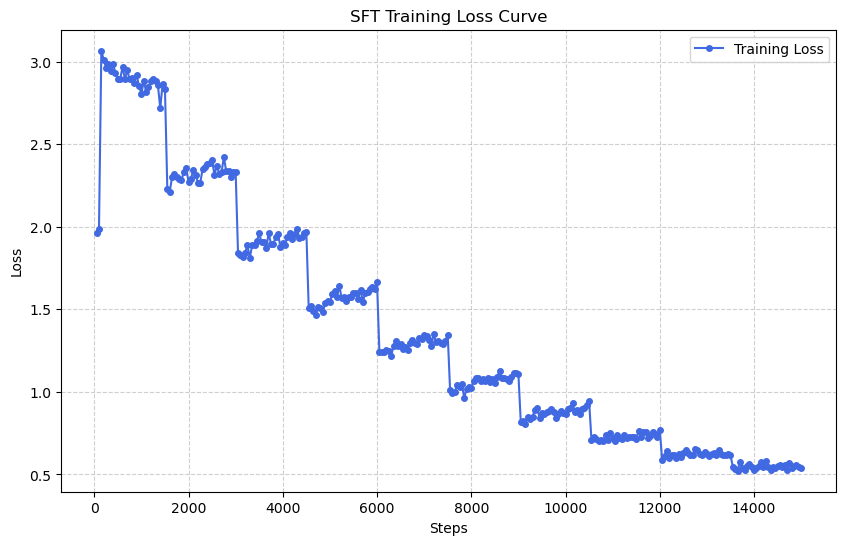

In [23]:
import matplotlib.pyplot as plt

# 1. 훈련 인자 설정 (logging_steps 추가)
training_args = transformers.TrainingArguments(
    output_dir="test",
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=5,
    prediction_loss_only=True,
    fp16=True,
    logging_steps=50,  # 50 스텝마다 로그를 남기도록 설정 (더 부드러운 곡선을 위해)
)

# 2. 트레이너 정의
trainer = transformers.Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset
)

# 3. 훈련 시작
trainer.train()

# 4. 모델 저장
model.save_pretrained('models/output_1_SFT')

# 5. trainer.state.log_history에서 Loss 기록 추출
loss_history = []
steps = []

for log in trainer.state.log_history:
    # log_history 리스트 안의 딕셔너리 중 'loss' 키가 있는 것만 추출
    if 'loss' in log:
        loss_history.append(log['loss'])
        steps.append(log['step'])

# 6. Loss 그래프 그리기
plt.figure(figsize=(10, 6))
plt.plot(steps, loss_history, label='Training Loss', color='royalblue', marker='o', markersize=4)
plt.title('SFT Training Loss Curve')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [25]:
generator = transformers.pipeline('text-generation', model='models/output_1_SFT', tokenizer=tokenizer)

generation_args = dict(
    num_beams=4,
    repetition_penalty=2.0,
    no_repeat_ngram_size=4,
    eos_token_id=375, # \n
    max_new_tokens=64,
    do_sample=True,
    top_k=50,
    early_stopping=True
)

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = ['불고기용 고기 한우에요?',
               '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
               '시카고 오헤어 국제공항은 어디에 있어?',
               '오늘 미세먼지 어때?']

list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt' : tmp}) for tmp in list_prompt]

list_result = generator(list_prompt, **generation_args)
for prompt, result in zip(list_prompt, list_result):
    print()
    print((result[0]['generated_text']))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'eos_token_id', 'max_new_tokens', 'top_k', 'early_stopping', 'no_repeat_ngram_size', 'num_beams', 'repetition_penalty'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=64) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even


### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):'저는 인공지능 어시스턴트이기 때문에 직접적으로 식품에 관한 정보를 가지고 있지는 않습니다. 하지만 일반적으로 불고기용 고기는 한우, 쇠고기, 돼지고기 등 다양한 종류의 고기를 사용합니다. 한우는 대표적인 고급 육류로 알려져 있기 때문에 한우를 사용하는 경우도 많습니다. 그러나 한우는 부위나 종류에 따라 다양한 요리가

### Instruction(명령어):
리처드 닉슨이 43대 부통령직을 수행한 년도는?

### Response(응답):'1953년입니다.\n\n1960년대 초반, 리처드 닉슨은 47대 부통령직을 수행했습니다. (출처: 클린턴 대통령 당선 후) (참여정부 당시) (한나라) (중)) (한) (정치)

### Instruction(명령어):
시카고 오헤어 국제공항은 어디에 있어?

### Response(응답):'시카고 오 헤어 국제공항은 미국 일리노이 주 시카고에 위치해 있습니다.: 시카고는 미국 일리노이 주의 시카고에 위치합니다.: 시카고의 유명한 관광지 중 하나입니다.\n\nEnglish: 미국 일리노이 주 시카고에는 다양한 호텔, 리조트, 골프장, 스파 등 다양한 시설이 있습니다.

### Instruction(명령어):
오늘 미세먼지 어때?

### Response(응답):'미세먼지 농도는 어제와 비교해서 개선되었지만 아직도 나쁜 수준이며, 마스크 착용과 실외 활동 자제를 권장합니다. 따라서 미세먼지 농도를 확인하려면 해당 지역의 미세먼지 측정소에서 확인해보시기 바랍니다. 또한, 외출 시 마스크를 착용하여 미세먼지를 줄이는 것도 좋은 방법입니다.


In [26]:
torch.cuda.empty_cache()

### STEP 2 - Reward Model (RM)

In [27]:
from chatgpt.dataset import RewardDataset
from chatgpt.models.base import RewardModel
from chatgpt.trainer.strategies import NaiveStrategy
from chatgpt.trainer.rm import RewardModelTrainer

from transformers.models.gpt2.configuration_gpt2 import GPT2Config
from transformers.models.gpt2.modeling_gpt2 import GPT2Model

import torch.nn as nn

import random

In [28]:
class GPTRM_custom(RewardModel):

    def __init__(self,
                 pretrained: Optional[str] = None,
                 config: Optional[GPT2Config] = None,
                 checkpoint: bool = False,
                 lora_rank: int = 0,
                 lora_train_bias: str = 'none',
                 tokenizer=None) -> None:
        if pretrained is not None:
            model = GPT2Model.from_pretrained(pretrained)
            model.resize_token_embeddings(len(tokenizer))
        elif config is not None:
            model = GPT2Model(config)
        else:
            model = GPT2Model(GPT2Config())
        if checkpoint:
            model.gradient_checkpointing_enable()

        value_head = nn.Linear(model.config.n_embd, 1)
        super().__init__(model, value_head, lora_rank, lora_train_bias)

        if pretrained is not None:
            self.model = model
            self.pretrained = pretrained


    def save_pretrained(self, dir):
        if self.pretrained is not None:
            self.model.save_pretrained(dir)

In [29]:
model = GPT2LMHeadModel.from_pretrained('skt/kogpt2-base-v2')
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

with NaiveStrategy().model_init_context():
        model = GPTRM_custom(pretrained='skt/kogpt2-base-v2', lora_rank=0, tokenizer=tokenizer).cuda()

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2Model LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
lm_head.weight                          | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [30]:
with open('/home/jovyan/work/KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl', "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)

total_data_ranking2chosen = []
for tmp in list_data_dict:
    one_data_ranking2chosen = []

    data = {}
    data['prompt'] = tmp['prompt']
    if tmp['ranking'][0] < tmp['ranking'][1]:
        data['chosen'] = tmp['completion_0']
        data['rejected'] = tmp['completion_1']
    else:
        data['chosen'] = tmp['completion_1']
        data['rejected'] = tmp['completion_0']
    one_data_ranking2chosen.append(data)

    data = {}
    data['prompt'] = tmp['prompt']
    if tmp['ranking'][0] < tmp['ranking'][2]:
        data['chosen'] = tmp['completion_0']
        data['rejected'] = tmp['completion_2']
    else:
        data['chosen'] = tmp['completion_2']
        data['rejected'] = tmp['completion_0']
    one_data_ranking2chosen.append(data)

    data = {}
    data['prompt'] = tmp['prompt']
    if tmp['ranking'][1] < tmp['ranking'][2]:
        data['chosen'] = tmp['completion_1']
        data['rejected'] = tmp['completion_2']
    else:
        data['chosen'] = tmp['completion_2']
        data['rejected'] = tmp['completion_1']
    one_data_ranking2chosen.append(data)



    total_data_ranking2chosen.extend(one_data_ranking2chosen)

print('before data num: %d'%(len(list_data_dict)))
print('after  data num: %d'%(len(total_data_ranking2chosen)))
print('data example: \n%s'%total_data_ranking2chosen[45])

before data num: 10220
after  data num: 30660
data example: 
{'prompt': '애플은 리사를 어떻게 처리했어', 'chosen': '애플이 누구인지 명확히 알 수 없어서, 리사가 누구인지와 어떤 상황에서 처리되었는지에 대한 추가적인 정보가 필요합니다. 따라서, 보다 정확한 답변을 제공할 수 없습니다.', 'rejected': '애플은 리사를 위해 고객 서비스 부서에서 고객 다양한 컴퓨터 관련 문제에 대해 응답하는 데 필요한 모든 지원을 제공했습니다. 사용자가 하드웨어 문제를 경험할 때, 전문가들은 필요한 수리(수리, 추가 부품 제공, 소프트웨어 업그레이드 등)을 제공해 드릴 수 있습니다. 또한, 사용자가 사용 방법 문제나 기타 문제를 경험할 때, 대화 상대로 사용자를 지원할 수 있는 전문 고객 서비스 직원들이 사용자에게 상담하고 도움을 주는 데 도움이 될 수 있는 정보를 제공합니다. 또한, 인터넷에서 제공되는 정보를 통해 문제를 해결하거나 고객 서비스 웹 사이트를 통해 자신의 문제를 진단할 수 있도록 하는 등 다양한 방법으로 리사를 처리해 왔습니다.'}


In [31]:
import random
random.seed(230319)
random.shuffle(total_data_ranking2chosen)
print(total_data_ranking2chosen[45])

{'prompt': '유아인이 류승완 감독을 만나 영화 베테랑의 시나리오를 받았던 곳은?', 'chosen': '유아인이 류승완 감독을 만나 영화 베테랑의 시나리오를 받았던 곳은 류승완의 사무실입니다.', 'rejected': '대구 영화사옥'}


In [32]:
train_data = total_data_ranking2chosen[:1000]
eval_data = total_data_ranking2chosen[1000:1200]

print(len(train_data))
print(len(eval_data))

train_dataset = RewardDataset(train_data, tokenizer, 512)
eval_dataset = RewardDataset(eval_data, tokenizer, 512)

1000
200


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [33]:
idx = 1
print('#'*70)
print('## prompt ##')
print(train_data[idx]['prompt'])
print('#'*70)
print('## chosen ##')
print(train_data[idx]['chosen'])
print('#'*70)
print('## rejected ##')
print(train_data[idx]['rejected'])

######################################################################
## prompt ##
흑고래의 무게는 어느 정도야
######################################################################
## chosen ##
흑고래의 평균 몸무게는 약 25~40톤 정도이지만, 최대 몸무게는 50톤 이상에 이를 수 있습니다.
######################################################################
## rejected ##
흑고래의 무게는 매우 다양하게 달라집니다. 약 200kg에서 10톤까지 달라질 수 있습니다.


In [34]:
trainer = RewardModelTrainer(model=model,
                             strategy=NaiveStrategy(),
                             optim=torch.optim.Adam(model.parameters(), lr=5e-5),
                             train_dataset=train_dataset,
                             eval_dataset=eval_dataset,
                             batch_size=4,
                             max_epochs=10)

In [ ]:
trainer.fit(use_lora=0)

model.save_pretrained('models/output_2_RM')

In [36]:
def inference_RM(input_text):
    input_ids = tokenizer.encode(input_text, return_tensors='pt').cuda()
    output = model(input_ids)
    output_reward = output.cpu().detach().numpy()[0]

    print('input: %s\nreward score: %.1f'%(input_text, output_reward))

    return output_reward

input_text = '인공지능은 똥멍청이 입니다'
output_reward = inference_RM(input_text=input_text)

input: 인공지능은 똥멍청이 입니다
reward score: 8.2


In [37]:
input_text = '인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.'

output_reward = inference_RM(input_text=input_text)

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다.
reward score: 6.0


In [38]:
input_text = "인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다."

output_reward = inference_RM(input_text=input_text)

input: 인공지능(AI)은 컴퓨터에서 음성 및 작성된 언어를 보고 이해하고 번역하고 데이터를 분석하고 추천하는 기능을 포함하여 다양한 고급 기능을 수행할 수 있는 일련의 기술입니다. AI는 현대적인 컴퓨팅 혁신에서 중추적인 역할을 하며 개인과 비즈니스의 가치를 창출합니다. 예를 들어 광학 문자 인식(OCR)은 AI를 사용해 이미지 및 문서에서 텍스트 및 데이터를 추출하고, 구조화되지 않은 콘텐츠를 비즈니스에 바로 사용할 수 있게 만들고, 유용한 정보를 창출합니다.
reward score: 3.5


In [39]:
input_text = "인공지능은 일반적으로 인간의 지능이 필요하거나 인간이 분석할 수 있는 것보다 규모가 큰 데이터를 포함하는 방식으로 추론, 학습 및 행동할 수 있는 컴퓨터 및 기계를 구축하는 것과 관련된 과학 분야입니다. AI는 컴퓨터 공학, 데이터 분석 및 통계, 하드웨어 및 소프트웨어 엔지니어링, 언어학, 신경 과학은 물론 철학과 심리학을 포함하여 여러 학문을 포괄하는 광범위한 분야입니다. 비즈니스의 운영 수준에서 AI는 주로 머신러닝과 딥 러닝을 기반으로 하는 기술 모음으로, 데이터 분석, 예상 및 예측, 객체 분류, 자연어 처리, 추천, 지능형 데이터 가져오기 등을 수행할 수 있습니다."

output_reward = inference_RM(input_text=input_text)

input: 인공지능은 일반적으로 인간의 지능이 필요하거나 인간이 분석할 수 있는 것보다 규모가 큰 데이터를 포함하는 방식으로 추론, 학습 및 행동할 수 있는 컴퓨터 및 기계를 구축하는 것과 관련된 과학 분야입니다. AI는 컴퓨터 공학, 데이터 분석 및 통계, 하드웨어 및 소프트웨어 엔지니어링, 언어학, 신경 과학은 물론 철학과 심리학을 포함하여 여러 학문을 포괄하는 광범위한 분야입니다. 비즈니스의 운영 수준에서 AI는 주로 머신러닝과 딥 러닝을 기반으로 하는 기술 모음으로, 데이터 분석, 예상 및 예측, 객체 분류, 자연어 처리, 추천, 지능형 데이터 가져오기 등을 수행할 수 있습니다.
reward score: 6.4


In [40]:
torch.cuda.empty_cache()

### STEP 3 - Proximal Policy Optimization(PPO) + SFT, RM models

In [41]:
from chatgpt.models.gpt import GPTActor, GPTCritic
from chatgpt.trainer import PPOTrainer

from copy import deepcopy

In [42]:
with NaiveStrategy().model_init_context():
    actor = GPTActor(pretrained='models/output_1_SFT', lora_rank=0).to(torch.cuda.current_device())
    critic = GPTCritic(pretrained='models/output_2_RM', lora_rank=0).to(torch.cuda.current_device())
    tokenizer = PreTrainedTokenizerFast.from_pretrained(
        'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
        padding_side="right",
        model_max_length=512
    )
    initial_model = deepcopy(actor)
    reward_model = RewardModel(deepcopy(critic.model), deepcopy(critic.value_head)).to(torch.cuda.current_device())

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [43]:
actor_optim = torch.optim.Adam(actor.parameters(), lr=5e-6)
critic_optim = torch.optim.Adam(critic.parameters(), lr=5e-6)

In [44]:
(actor, actor_optim), (critic, critic_optim), reward_model, initial_model = NaiveStrategy().prepare(
    (actor, actor_optim), (critic, critic_optim), reward_model, initial_model)

In [45]:
with open('/home/jovyan/work/KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl', "r", encoding='utf-8-sig') as json_file:
    list_data_dict = json.load(json_file)
    list_prompt = [tmp['prompt'] for tmp in list_data_dict]

def tokenize_fn(texts):
    batch = tokenizer(texts, return_tensors='pt', max_length=96, padding=True, truncation=True)
    return {k: v.cuda() for k, v in batch.items()}

In [46]:
print(tokenize_fn('It takes something more than intelligence to act intelligently.'))

{'input_ids': tensor([[47311, 10448, 19008,  9792, 11780, 11308, 30190, 10929, 11849, 21663,
         44389,  9574, 13799,   458, 14308, 12778, 22469, 20938, 44696,   458,
         13799,   458, 14308, 12778, 11756, 18944,   389]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1]], device='cuda:0')}


In [47]:
len(list_prompt)

12000

Train epoch [1/10]: 100%|██████████| 3/3 [00:01<00:00,  1.96it/s, actor_loss=2.8, critic_loss=39.4]

Train epoch [2/10]: 100%|██████████| 3/3 [00:01<00:00,  1.98it/s, actor_loss=3.58, critic_loss=42.8]

Train epoch [3/10]: 100%|██████████| 3/3 [00:01<00:00,  1.97it/s, actor_loss=5.46, critic_loss=186]

Train epoch [4/10]: 100%|██████████| 3/3 [00:01<00:00,  1.98it/s, actor_loss=1.94, critic_loss=40.1]

Train epoch [5/10]: 100%|██████████| 3/3 [00:01<00:00,  1.97it/s, actor_loss=0.285, critic_loss=0.75]

Train epoch [6/10]: 100%|██████████| 3/3 [00:01<00:00,  1.97it/s, actor_loss=3.5, critic_loss=147]

Train epoch [7/10]: 100%|██████████| 3/3 [00:01<00:00,  1.97it/s, actor_loss=2.33, critic_loss=41.8]

Train epoch [8/10]: 100%|██████████| 3/3 [00:01<00:00,  1.97it/s, actor_loss=4.01, critic_loss=150]

Train epoch [9/10]: 100%|██████████| 3/3 [00:01<00:00,  1.97it/s, actor_loss=4.04, critic_loss=151]

Train epoch [1/10]: 100%|██████████| 3/3 [00:01<00:00,  1.93it/s, actor_loss=-0.432, cr

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

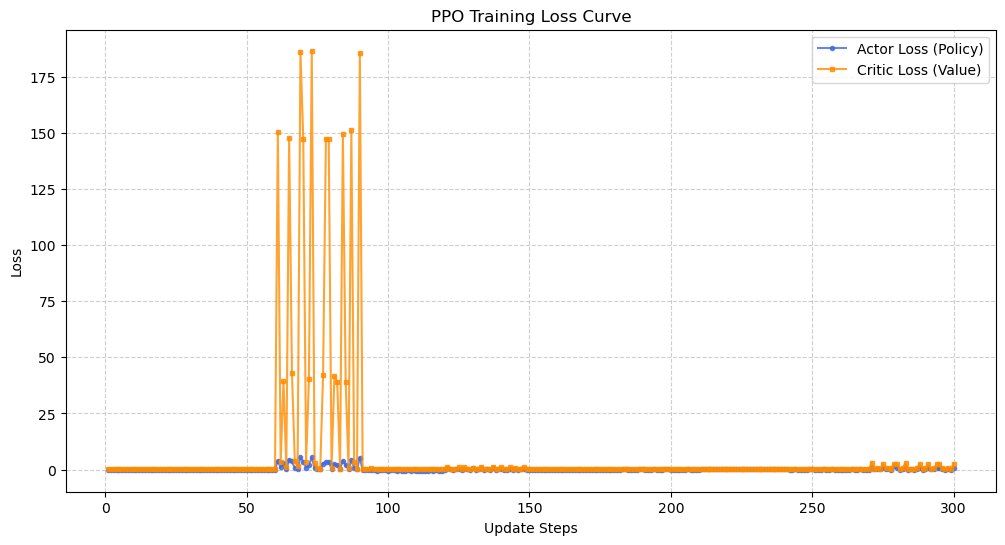

In [48]:
import matplotlib.pyplot as plt

trainer = PPOTrainer(NaiveStrategy(),
                     actor,
                     critic,
                     reward_model,
                     initial_model,
                     actor_optim,
                     critic_optim,
                     max_epochs=10,
                     train_batch_size=8,
                     tokenizer=tokenize_fn,
                     max_length=128,
                     do_sample=True,
                     temperature=1.0,
                     top_k=50,
                     pad_token_id=tokenizer.pad_token_id,
                     eos_token_id=tokenizer.eos_token_id)

# ---------------------------------------------------------
# 추가된 부분: Actor와 Critic의 Loss 가로채기
# ---------------------------------------------------------
actor_losses = []
critic_losses = []

original_backward = trainer.strategy.backward

def patched_backward(loss, model, optimizer):
    # 어떤 옵티마이저가 들어왔는지 확인하여 각각의 리스트에 따로 저장합니다.
    if optimizer is actor_optim:
        actor_losses.append(loss.item())
    elif optimizer is critic_optim:
        critic_losses.append(loss.item())
    
    # 원래의 backward 연산 수행
    original_backward(loss, model, optimizer)

# 트레이너의 backward 함수를 바꿔치기
trainer.strategy.backward = patched_backward
# ---------------------------------------------------------

# --- 원본 코드 유지 ---
trainer.fit(list_prompt,
            num_episodes=10,
            max_timesteps=3,
            update_timesteps=3)

actor.model.save_pretrained('models/output_3_PPO')

# ---------------------------------------------------------
# 추가된 부분: PPO Loss 그래프 그리기 (두 개의 선)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Actor와 Critic의 업데이트 횟수가 같으므로 x축(steps)은 리스트의 길이를 사용합니다.
steps = range(1, len(actor_losses) + 1)

plt.plot(steps, actor_losses, label='Actor Loss (Policy)', color='royalblue', marker='o', markersize=3, alpha=0.8)
plt.plot(steps, critic_losses, label='Critic Loss (Value)', color='darkorange', marker='s', markersize=3, alpha=0.8)

plt.title('PPO Training Loss Curve')
plt.xlabel('Update Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [49]:
def generation(input_text, model):
    input_ids = tokenizer.encode(input_text, return_tensors='pt').to(
        torch.cuda.current_device())
    outputs = model.generate(input_ids,
                             max_length=250,
                             do_sample=True,
                             top_k=50,
                             top_p=0.95,
                             num_return_sequences=1)
    output = tokenizer.batch_decode(outputs[0], skip_special_tokens=True)[0]
    print()
    print(output)
    return output

PROMPT_DICT = {
    "prompt_input": (
        "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    )
}

list_prompt = [
    '불고기용 고기 한우에요?',
    '리처드 닉슨이 43대 부통령직을 수행한 년도는?',
    '시카고 오헤어 국제공항은 어디에 있어',
    '오늘 미세먼지 어때?']

list_prompt = [PROMPT_DICT['prompt_input'].format_map({'prompt': tmp}) for tmp in list_prompt]

for input_text in list_prompt:
    output = generation(input_text, actor)


### Instruction(명령어):
불고기용 고기 한우에요?

### Response(응답):'저는 인공지능 언어모델입니다. 질문이 불분명하여 답변을 드리기 어렵습니다. 어떤 종류의 고기를 원하시는지 알려주시면 더 자세한 답변을 드릴 수 있습니다. 감사합니다. 뉴스 기사:\n\n[한우] 중앙일보·TV리포트)입니다. 서울시 한우는 100% 경기도 고양시에서 출생합니다. 중앙일보와 같은 언론 기관에 근무하셨습니다. 서울: \n\n[학교:\n\n{'한우] 유통업: \n\n세종과학고·중식)은 100% 경기도 고양에서 태어나습니다. 02 는 현재 중앙일보에서 출제되지 않았습니다. a구글변) 재정적으로 성공하는 교육기관은 없습니다.恩중학교, 02 는 현재 다니는 학교를 알고 있습니다. 중앙일보와 같은 대형 언론기관이 있는 것은 아니므로, 정확한 답변을 드리기 어렵습니다. 중식 레스토랑 등)는행을 수강하고 있습니다. 중앙일보와 같은 공공기관에서 근무하셨습니다. 02 

### Instruction(명령어):
리처드 닉슨이 43대 부통령직을 수행한 년도는?

### Response(응답):'1935년입니다. 寅島理仁成堂書店)이 있습니다. 1970년에는 로버트 썬이 부통령을 수행한 것으로 알려져 있습니다. 감청정책 법률 위반 혐의 등으로 직무정지가 된 상태입니다. 寅島理仁成堂書店)은 이완용 전 대사금지가 아니므로, 해당 연도에 해당할 수 있습니다.島理仁堂書店)은 이완용 전 대사금지가 아니며, 당시 대선 후보로 출마한 이완용 등이 있었습니다. 201 참고용으로서는 감정 출처는 밝혀지지 않습니다.島理仁成堂書店)은 이완용 대사에게 연도와 연대를 밝히지 말았습니다. 寅島理仁成堂書店)은 이완용 대사금지가 아니며, 당시 대선 후보인 이완용 등이 있던 시기였습니다. 201 참고용으로서는庚寅島理人成堂書店)에서 조사와 태도를 나타내면서도 감사위원회

### Instruction(명령어):
시카고 오헤어 국제공항은 어디에 있어

### Response(응답):'시카고 오헤어 국제공항은 미

---
## Base Model vs PPO Model 비교 평가

In [ ]:
!pip install nltk rouge-score

### 정량적 평가 (BLEU, ROUGE)

In [55]:
import json
import random
import numpy as np
import pandas as pd
import torch
from transformers import GPT2LMHeadModel, PreTrainedTokenizerFast

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# --- 1. 토크나이저 & 모델 로딩 ---
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer_eval = PreTrainedTokenizerFast.from_pretrained(
    "skt/kogpt2-base-v2", bos_token="</s>", eos_token="</s>",
    unk_token="</s>", pad_token="</s>",
    padding_side="right", model_max_length=512,
)

base_model = GPT2LMHeadModel.from_pretrained("skt/kogpt2-base-v2").to(device)
ppo_model  = GPT2LMHeadModel.from_pretrained("models/output_3_PPO").to(device)
base_model.eval()
ppo_model.eval()

# --- 2. SFT 데이터에서 평가용 샘플 추출 ---
data_path_1_SFT = "/home/jovyan/work/KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl"
with open(data_path_1_SFT, "r", encoding="utf-8-sig") as f:
    sft_data = json.load(f)

random.seed(42)
eval_samples = random.sample(sft_data, 50)

# --- 3. 응답 생성 함수 ---
PROMPT_TEMPLATE = "### Instruction(명령어):"
{prompt}

### Response(응답):"

def generate_response(model, prompt_text, max_new=64):
    formatted = PROMPT_TEMPLATE.format(prompt=prompt_text)
    input_ids = tokenizer_eval.encode(formatted, return_tensors="pt").to(device)
    with torch.no_grad():
        output = model.generate(
            input_ids,
            max_new_tokens=max_new,
            num_beams=4,
            no_repeat_ngram_size=4,
            repetition_penalty=2.0,
            do_sample=True,
            top_k=50,
            early_stopping=True,
        )
    decoded = tokenizer_eval.decode(output[0], skip_special_tokens=True)
    # "### Response(응답):" 이후 텍스트만 추출
    if "### Response(응답):" in decoded:
        decoded = decoded.split("### Response(응답):")[-1].strip()
    return decoded

# --- 4. BLEU & ROUGE 계산 ---
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)
smooth = SmoothingFunction().method1

results = {"base": {"bleu": [], "rouge1": [], "rouge2": [], "rougeL": []},
           "ppo":  {"bleu": [], "rouge1": [], "rouge2": [], "rougeL": []}}

print("평가 진행 중... (50개 샘플)")
for i, sample in enumerate(eval_samples):
    reference = sample["completion"]
    prompt    = sample["prompt"]
    ref_tokens = list(reference)  # 한국어: 글자 단위 토큰화

    for name, mdl in [("base", base_model), ("ppo", ppo_model)]:
        generated = generate_response(mdl, prompt)
        gen_tokens = list(generated)

        # BLEU (글자 단위)
        bleu = sentence_bleu([ref_tokens], gen_tokens, smoothing_function=smooth)
        results[name]["bleu"].append(bleu)

        # ROUGE
        rouge = scorer.score(reference, generated)
        results[name]["rouge1"].append(rouge["rouge1"].fmeasure)
        results[name]["rouge2"].append(rouge["rouge2"].fmeasure)
        results[name]["rougeL"].append(rouge["rougeL"].fmeasure)

    if (i + 1) % 10 == 0:
        print(f"  {i + 1}/50 완료")

# --- 5. 결과 표 출력 ---
summary = pd.DataFrame({
    "Metric":     ["BLEU", "ROUGE-1", "ROUGE-2", "ROUGE-L"],
    "Base Model": [np.mean(results["base"]["bleu"]),
                   np.mean(results["base"]["rouge1"]),
                   np.mean(results["base"]["rouge2"]),
                   np.mean(results["base"]["rougeL"])],
    "PPO Model":  [np.mean(results["ppo"]["bleu"]),
                   np.mean(results["ppo"]["rouge1"]),
                   np.mean(results["ppo"]["rouge2"]),
                   np.mean(results["ppo"]["rougeL"])],
})
summary["Diff (PPO - Base)"] = summary["PPO Model"] - summary["Base Model"]
summary[["Base Model", "PPO Model", "Diff (PPO - Base)"]] = summary[["Base Model", "PPO Model", "Diff (PPO - Base)"]].round(4)

print(" " + "="*60)
print("📊 정량적 평가 결과 (50개 샘플 평균)")
print("="*60)
print(summary.to_string(index=False))
print("="*60)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

평가 진행 중... (50개 샘플)
  10/50 완료
  20/50 완료
  30/50 완료
  40/50 완료
  50/50 완료
📊 정량적 평가 결과 (50개 샘플 평균)
 Metric  Base Model  PPO Model  Diff (PPO - Base)
   BLEU      0.0037     0.0630             0.0594
ROUGE-1      0.0000     0.0133             0.0133
ROUGE-2      0.0000     0.0000             0.0000
ROUGE-L      0.0000     0.0133             0.0133


### 정성적 평가

In [59]:
list_prompt_eval = [
    "불고기용 고기 한우에요?",
    "리처드 닉슨이 43대 부통령직을 수행한 년도는?",
    "시카고 오헤어 국제공항은 어디에 있어",
    "오늘 미세먼지 어때?",
]

print("=" * 80)
print("📝 정성적 평가: Base Model vs PPO Model 응답 비교")
print("=" * 80)

for idx, prompt in enumerate(list_prompt_eval, 1):
    base_response = generate_response(base_model, prompt, max_new=128)
    ppo_response  = generate_response(ppo_model, prompt, max_new=128)

    print(f"{'─' * 80}")
    print(f"질문 {idx}: {prompt}")
    print(f"{'─' * 80}")
    print(f"🔹 [Base Model 응답]")
    print(f"   {base_response}")
    print(f"🔸 [PPO Model 응답]")
    print(f"   {ppo_response}")

print(f"{'═' * 80}")
print("비교 완료!")

📝 정성적 평가: Base Model vs PPO Model 응답 비교
────────────────────────────────────────────────────────────────────────────────
질문 1: 불고기용 고기 한우에요?
────────────────────────────────────────────────────────────────────────────────
🔹 [Base Model 응답]
   ### Instruction(명령어):
#instaphoto #instadaily #dailypic #like4like #selfie #셀카 #셀피 #얼스타그램 #소통 #맞팔 #선팔 #일상 #데일리 #좋아요
#인친 #훈남 #sonya9 #mensstyle #catsoninstagram #photooftheday #scottisholden #kitty #nek
🔸 [PPO Model 응답]
   ### Instruction(명령어):'죄송합니다. 제가 무엇을 도와드릴 수 있을까요? 더 자세한 내용을 알려주세요.
────────────────────────────────────────────────────────────────────────────────
질문 2: 리처드 닉슨이 43대 부통령직을 수행한 년도는?
────────────────────────────────────────────────────────────────────────────────
🔹 [Base Model 응답]
   ### Instruction(명령어): #certification #instadaily #dailylook #like4like #selfie #셀카 #셀피 #얼스타그램 #데일리룩 #소통 #팔로우 #좋아요
#선팔 #맞팔 #선팔하면맞팔 #2017프로젝트_에일린 
이번엔 바로 #블랙야크 !!!!!
오늘은 블랙야크 블랙야크 화이트셔츠입니다!

🔸 [PPO Model 응답]
   ### Instruction(명령어):'죄송합니다, 제가 무엇에 대한 질문인지 